# Ejercicio Formativo 3 Capitulo 2

## Importando librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

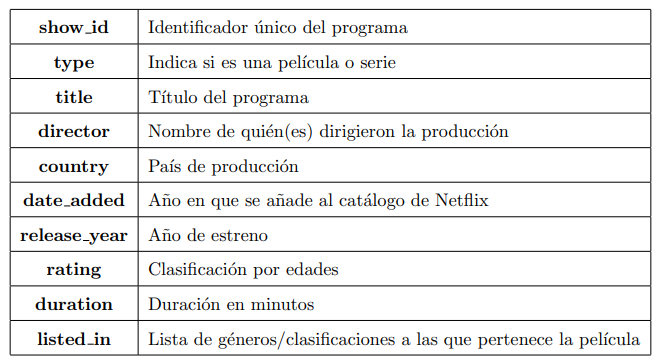

## 1. Carga y exploración:

"cargue el archivo con los datos y describa su contenido, indicando qué columnas
tienen información incompleta. Finalmente, visualice las variables, con el fin de evaluar la existencia
de outliers.
"

In [2]:
df = pd.read_csv("E3_data.csv")
df.head(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [3]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
country,object
date_added,object
release_year,int64
rating,object
duration,object
listed_in,object


In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


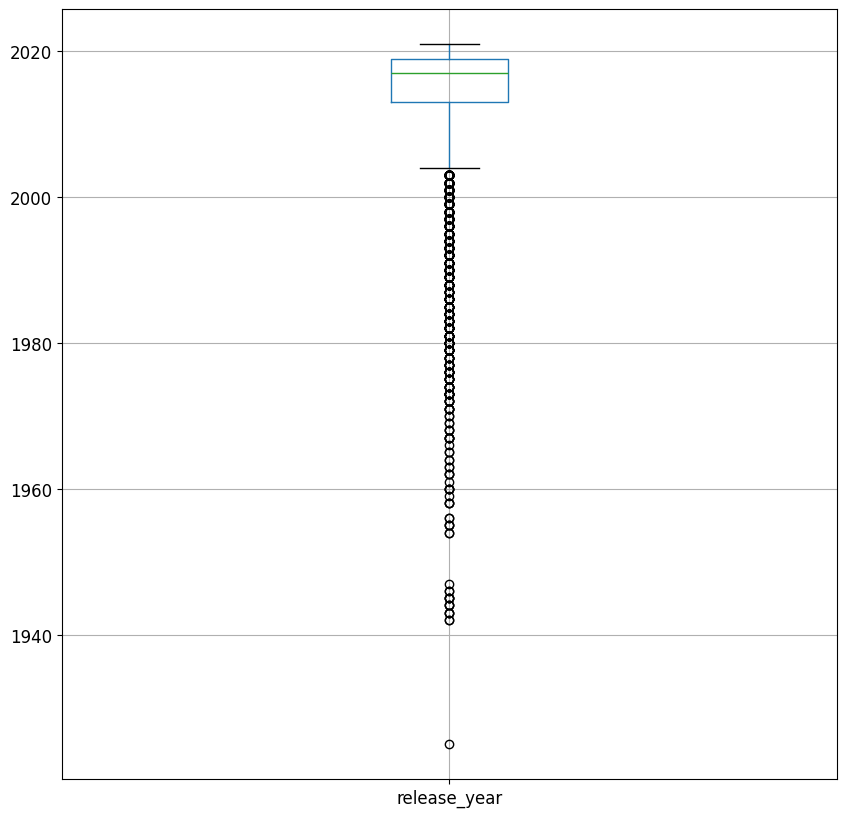

In [6]:
df.boxplot(column='release_year', fontsize=12, figsize=(10, 10))
plt.show()

## 2. Imputación y eliminación

"revise la presencia de elementos duplicados y decida cómo manejarlos.
Luego, resuelva el problema de la información faltante. Para cada una de las columnas con elementos
faltantes, impute los valores en base a algún criterio decidido por usted y basado en los datos. Además
de esto, analice y comente sobre la posible eliminación de filas completas en base a los valores faltantes."

In [7]:
df.duplicated().value_counts()

,count
False,8790


## 3. Expandir el dataset

"considerando los datos que contiene la columna listed in, genere un nuevo
DataFrame que tenga por cada show id, columnas binarias indicando si el programa pertenece a una
de las siguientes categorías:
* Action & Adventure
* Comedy
* Drama
* Horror
* Mystery
* Sci-Fi & Fantasy
* Thrillers
* Independent
* Children & Family

Tenga cuidado con categorías que sean sinónimos o palabras que se escriban en plural. Como último
paso, debe unir este DataFrame con el original."

In [8]:
df_exploded = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
generos_totales = df_exploded['listed_in'].values
print(generos_totales)
df_exploded

['Documentaries' 'Crime TV Shows' 'International TV Shows' ... 'TV Dramas'
 "Kids' TV" "Kids' TV"]


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,Crime TV Shows
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,International TV Shows
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,TV Action & Adventure
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,TV Dramas
...,...,...,...,...,...,...,...,...,...,...
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,International TV Shows
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,Romantic TV Shows
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,TV Dramas
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [9]:
categorias = {
    "Action & Adventure": ["Action", "Adventure"],
    "Comedy": ["Comedy"],
    "Drama": ["Drama"],
    "Horror": ["Horror"],
    "Mystery": ["Mystery"],
    "Sci-Fi & Fantasy": ["Sci-Fi", "Science Fiction", "Fantasy"],
    "Thrillers": ["Thriller"],
    "Independent": ["Independent"],
    "Children & Family": ["Children", "Family", "Kids"]
}

for categoria, keywords in categorias.items():
    df_exploded[categoria] = df_exploded['listed_in'].apply(lambda x: any(kw in x for kw in keywords))

df_exploded[list(categorias.keys())] = df_exploded[list(categorias.keys())].astype(int)

df_final = df_exploded.groupby('show_id', as_index=False)[list(categorias.keys())].max()

df["categoria_binaria_unica"] = df_final[categorias.keys()].max(axis=1)

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,categoria_binaria_unica
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries,0
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies",1
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",1


## 4. Consultas

"conteste cada una de las siguientes consultas, justificando los análisis y supuestos realizados:"

### a) ¿Cuál es el género con más presencia en los últimos 5 años? ¿En qué década hay más películas de ese género? ¿Y qué país ha producido más películas de este tipo?

In [10]:
ultimo_año = df['release_year'].max()
df_ultimas = df[df['release_year'] >= (ultimo_año-5)]
df_ultimas['listed_in'].value_counts()

,count
listed_in,
Documentaries,286
Stand-Up Comedy,250
"Dramas, International Movies",216
"Dramas, Independent Movies, International Movies",167
Kids' TV,157
...,...
"Romantic TV Shows, TV Dramas, TV Sci-Fi & Fantasy",1
"Reality TV, Science & Nature TV",1
"Kids' TV, Reality TV, TV Dramas",1


In [11]:
df_documentaries = df[df['listed_in'] == "Documentaries"]
df_documentaries['release_year'].value_counts()

,count
release_year,
2017,89
2016,67
2018,54
2019,33
2015,26
2020,23
2021,20
2014,12
2013,10


In [12]:
df_documentaries['country'].value_counts()

,count
country,
United States,269
United Kingdom,47
Canada,12
Not Given,9
Pakistan,5
Denmark,3
Sweden,2
New Zealand,1
Poland,1


### b) En promedio, ¿cuánto demora en llegar un programa al catálogo de Netflix? Para películas anteriores a la creación de Netflix, utilice la fecha de la creación del catálogo de streaming (2008) para sus cálculos.


In [13]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['release_year'] = df['release_year'].apply(lambda x: max(x, 2008))
df['años_para_agregar'] = df['date_added'].dt.year - df['release_year']
promedio_espera = df['años_para_agregar'].mean()
print(f"El promedio de años para agregar es: {promedio_espera:.2f}")

El promedio de años para agregar es: 3.15


### c) Visualice y analice cómo ha cambiado en el tiempo la clasificación por edades del género de Horror.

<Figure size 1200x600 with 0 Axes>

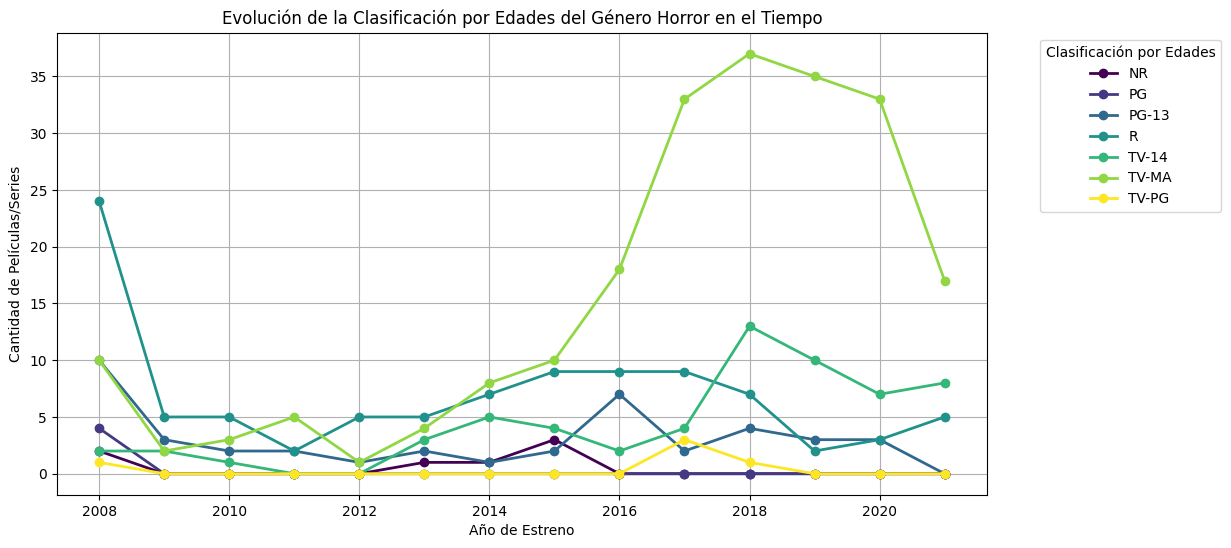

In [24]:
df_horror = df[df['listed_in'].str.contains("Horror", case=False, na=False)]
df_horror_grouped = df_horror.sort_values('release_year').groupby(['release_year', 'rating']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
df_horror_grouped.plot(kind='line', marker='o', colormap='viridis', linewidth=2, figsize=(12,6))

# Configurar etiquetas y título
plt.xlabel("Año de Estreno")
plt.ylabel("Cantidad de Películas/Series")
plt.title("Evolución de la Clasificación por Edades del Género Horror en el Tiempo")
plt.legend(title="Clasificación por Edades", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()